# 위험중립형 전략 포트폴리오 백테스팅

| 항목 | 내용 |
|------|------|
| 전략 | `neutral` — 위험중립형 (ADX 25, 분할 진입 40%→70%) |
| 투자금액 | 100만원 |
| 기간 | 2019 ~ 2025 |
| 종목 수 | 5개 포트폴리오 |
| 방법 | Walk-Forward (IS 12개월 학습 → OOS 3개월 적용) |

**실행 순서**: 셀을 위에서 아래로 순서대로 실행

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import koreanize_matplotlib

from stock_system.profiles import get_profile
from stock_system.backtest.portfolio import run_walk_forward, run_bh_portfolio
from stock_system.backtest.metrics import build_metrics_table, build_period_stats_table
from stock_system.backtest.plots.performance import (
    plot_equity_curves,
    plot_weight_heatmap,
    plot_contribution,
    plot_diversification,
    plot_yearly_returns,
    plot_yearly_pnl,
    plot_mdd_comparison,
    plot_quarterly_returns,
    plot_monthly_heatmap,
)
from stock_system.backtest.plots.strategy import plot_regime

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 기본 설정

In [2]:
PROFILE_NAME    = 'neutral'
INITIAL_CAPITAL = 1_000_000   # 100만원
START_DATE      = '2019-01-01'
END_DATE        = '2025-12-31'

profile = get_profile(PROFILE_NAME)

print(f'전략        : {PROFILE_NAME} (위험중립형)')
print(f'초기 자본   : {INITIAL_CAPITAL:,}원  ({INITIAL_CAPITAL // 10_000}만원)')
print(f'백테스팅 기간: {START_DATE} ~ {END_DATE}')
print()
print(f'  ADX 임계값    : {profile.ADX_THRESHOLD}')
print(f'  ADX 횡보 기준 : {profile.ADX_SIDEWAYS}')
print(f'  1차 진입 비중 : {profile.ENTRY1_SIZE:.0%}')
print(f'  2차 진입 비중 : {profile.ENTRY2_SIZE:.0%}')
print(f'  횡보 진입 비중: {profile.ENTRY_RANGE_SIZE:.0%}')
print(f'  ATR 승수      : {profile.ATR_MULTIPLIER}')
print(f'  수수료        : {profile.FEES:.2%}')
print(f'  슬리피지      : {profile.SLIPPAGE:.2%}')
print(f'  WF 학습 기간  : {profile.WF_TRAIN_MONTHS}개월')
print(f'  WF 검증 기간  : {profile.WF_TEST_MONTHS}개월')

전략        : neutral (위험중립형)
초기 자본   : 1,000,000원  (100만원)
백테스팅 기간: 2019-01-01 ~ 2025-12-31

  ADX 임계값    : 25.0
  ADX 횡보 기준 : 20.0
  1차 진입 비중 : 40%
  2차 진입 비중 : 70%
  횡보 진입 비중: 30%
  ATR 승수      : 2.0
  수수료        : 0.15%
  슬리피지      : 0.10%
  WF 학습 기간  : 12개월
  WF 검증 기간  : 3개월


---
## 2. 포트폴리오 종목 선택

섹터 분산을 고려한 국내 대표 우량주 5종목 구성

| 종목 | 티커 | 섹터 |
|------|------|------|
| 삼성전자 | 005930.KS | 반도체/전자 |
| SK하이닉스 | 000660.KS | 반도체 |
| 현대차 | 005380.KS | 자동차 |
| NAVER | 035420.KS | 인터넷 |
| KB금융 | 105560.KS | 금융 |

In [3]:
STOCKS = {
    '삼성전자'  : '005930.KS',
    'SK하이닉스' : '000660.KS',
    '현대차'    : '005380.KS',
    'NAVER'     : '035420.KS',
    'KB금융'    : '105560.KS',
}

KOSPI_TICKER    = '^KS11'      # KOSPI 벤치마크
CASH_ETF_TICKER = '153130.KS'  # KODEX 단기채권 (현금 대기 수익화)
CASH_ETF_NAME   = '단기채'

names   = list(STOCKS.keys())
tickers = list(STOCKS.values())

print(f'포트폴리오 종목 ({len(STOCKS)}개):')
for name, ticker in STOCKS.items():
    print(f'  {name:12s}: {ticker}')
print(f'\nKOSPI   : {KOSPI_TICKER}')
print(f'현금 ETF : {CASH_ETF_TICKER}')

포트폴리오 종목 (5개):
  삼성전자        : 005930.KS
  SK하이닉스      : 000660.KS
  현대차         : 005380.KS
  NAVER       : 035420.KS
  KB금융        : 105560.KS

KOSPI   : ^KS11
현금 ETF : 153130.KS


---
## 3. 데이터 다운로드

In [4]:
dl_tickers = tickers + [KOSPI_TICKER, CASH_ETF_TICKER]

raw = yf.download(dl_tickers, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

def _get(field, cols):
    return raw[field][cols].ffill()

close_df = _get('Close', tickers).rename(columns=dict(zip(tickers, names)))
high_df  = _get('High',  tickers).rename(columns=dict(zip(tickers, names)))
low_df   = _get('Low',   tickers).rename(columns=dict(zip(tickers, names)))

# 전 종목 데이터가 없는 날 제거
valid = close_df.notna().all(axis=1)
close_df, high_df, low_df = close_df[valid], high_df[valid], low_df[valid]

kospi    = _get('Close', [KOSPI_TICKER])[KOSPI_TICKER]
cash_etf = _get('Close', [CASH_ETF_TICKER])[CASH_ETF_TICKER]

print(f'데이터 기간: {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'총 영업일수: {len(close_df)}일')
print(f'종목 수    : {len(names)}개')
close_df.tail(3)

데이터 기간: 2019-01-02 ~ 2025-12-30
총 영업일수: 1717일
종목 수    : 5개


Ticker,삼성전자,SK하이닉스,현대차,NAVER,KB금융
Date,,,,,
2025-12-26,116193.500000,597896.7500,284750.00000,229093.500000,122519.796875
2025-12-29,119253.171875,638821.2500,292217.21875,239484.359375,123503.101562
2025-12-30,119652.343750,649800.9375,295204.09375,239979.156250,122618.132812


---
## 4. 대표 종목 4국면 미리보기

| 국면 | 색상 | 조건 |
|------|------|------|
| UPTREND | 초록 | MA20 > MA60 > MA120 & ADX > 25 |
| DOWNTREND | 빨강 | MA20 < MA60 < MA120 & ADX > 25 |
| SIDEWAYS | 주황 | ADX < 20 |
| TRANSITION | 회색 | 나머지 |

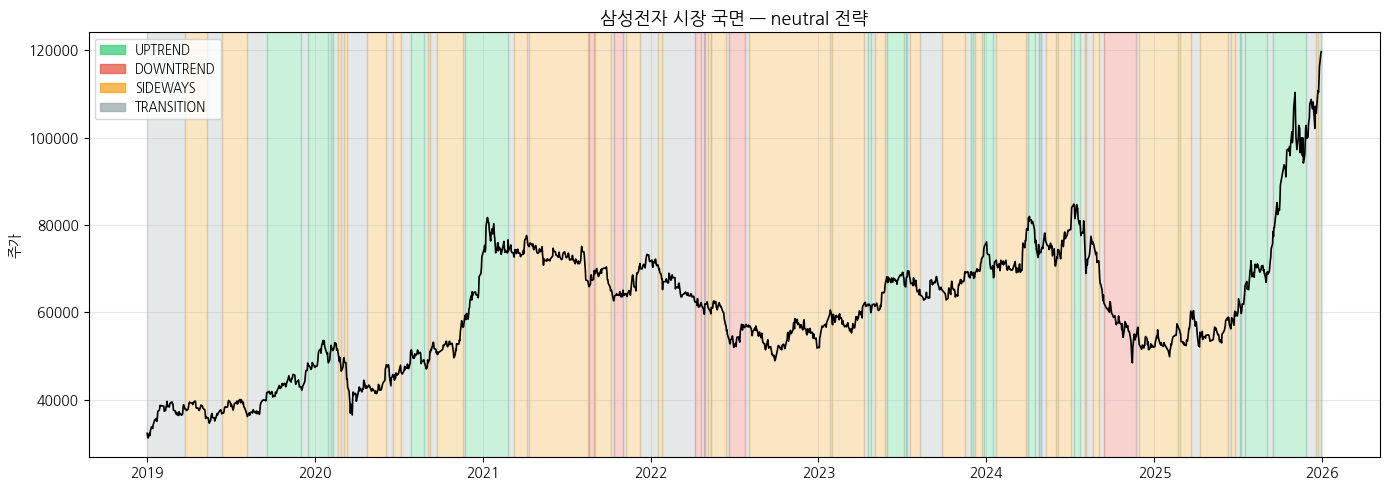


=== 국면 비율 ===
  UPTREND     :  313일  (18.2%)
  DOWNTREND   :  101일  (5.9%)
  SIDEWAYS    :  788일  (45.9%)
  TRANSITION  :  515일  (30.0%)


In [5]:
sample = names[0]  # 삼성전자

_, _, _, detail = profile.make_signals(
    close_df[sample], high_df[sample], low_df[sample],
    adx_threshold=profile.ADX_THRESHOLD,
    adx_sideways=profile.ADX_SIDEWAYS,
    kospi=kospi,
)

plot_regime(
    close_df[sample],
    detail['regime'],
    title=f'{sample} 시장 국면 — {PROFILE_NAME} 전략',
)

---
## 5. Walk-Forward 백테스팅 실행

- **IS(In-Sample)**: 12개월 구간에서 종목별 독립 ADX 파라미터 그리드 서치
- **OOS(Out-of-Sample)**: 종목별 최적 파라미터로 3개월 실전 적용
- IS score > 0 → ADX 모드 / IS score ≤ 0 → MA+KOSPI 모드 (종목별 독립 결정)

In [6]:
print('Walk-Forward 백테스팅 실행 중 ...')

pf_wf, wf_info = run_walk_forward(
    profile,
    close_df, high_df, low_df,
    kospi=kospi,
    cash_etf=cash_etf,
    init_cash=INITIAL_CAPITAL,
)

pf_bh = run_bh_portfolio(
    close_df,
    fees=profile.FEES,
    slippage=profile.SLIPPAGE,
    init_cash=INITIAL_CAPITAL,
)

print(f'완료 — {wf_info["n_windows"]}개 WF 구간')
print()

rows = []
for i, w in enumerate(wf_info['windows'], 1):
    for name, sp in w['per_stock'].items():
        p  = sp['best_params']
        sc = sp['best_score']
        rows.append({
            '#':        i,
            'OOS 기간': f'{w["test_start"].date()} ~ {w["test_end"].date()}',
            '종목':     name,
            'adx_thr':  int(p.get('adx_threshold')),
            'adx_sw':   int(p.get('adx_sideways')),
            'IS score': round(sc, 3) if pd.notna(sc) else float('nan'),
            '모드':     'ADX' if sp['use_adx_mode'] else 'MA+KOSPI',
        })

pd.DataFrame(rows).set_index(['#', '종목'])

Walk-Forward 백테스팅 실행 중 ...
완료 — 23개 WF 구간



OOS 기간  adx_thr  adx_sw  IS score        모드
#  종목                                                                  
1  삼성전자    2020-01-02 ~ 2020-04-01       15      20     1.994       ADX
   SK하이닉스  2020-01-02 ~ 2020-04-01       30      10     3.158       ADX
   현대차     2020-01-02 ~ 2020-04-01       20      15     0.790       ADX
   NAVER   2020-01-02 ~ 2020-04-01       15      20     3.786       ADX
   KB금융    2020-01-02 ~ 2020-04-01       15      15     1.372       ADX
...                            ...      ...     ...       ...       ...
23 삼성전자    2025-07-02 ~ 2025-10-01       25      20     6.269       ADX
   SK하이닉스  2025-07-02 ~ 2025-10-01       20      10     2.077       ADX
   현대차     2025-07-02 ~ 2025-10-01       15      20     3.311       ADX
   NAVER   2025-07-02 ~ 2025-10-01       20      10    -0.458  MA+KOSPI
   KB금융    2025-07-02 ~ 2025-10-01       15      20     1.831       ADX

[115 rows x 5 columns]

---
## 6. 결과 분석

### 6-1. 성과 지표 테이블

| 상태 | 의미 |
|------|------|
| ✓ | 목표 달성 |
| ⚠ | 경보선 이상, 목표 미달 |
| ✗ | 경보선 미달 |
| — | 해당 없음 |

In [7]:
tbl = build_metrics_table(pf_wf, pf_bh, close_df, profile, benchmark_series=kospi)
print(f'=== {PROFILE_NAME} 전략 성과 지표  [초기 자본: {INITIAL_CAPITAL:,}원] ===\n')
tbl

=== neutral 전략 성과 지표  [초기 자본: 1,000,000원] ===



,neutral 전략,B&H,목표,경보선,상태
지표,,,,,
CAGR,14.93%,25.47%,6.00%,4.00%,✓
MDD,-30.35%,-37.78%,-25.00%,-35.00%,✓
MDD기간(월),36.1,31.3,12.0,18.0,✗
Calmar,0.49,0.67,0.30,0.20,✓
Sortino,1.13,1.61,0.50,0.30,✓
Alpha,+3.36%,+14.74%,+2.00%,+0.00%,✓
Beta,0.56,1.10,0.80,1.00,✓
MDD감소율,-15.02%,5.79%,20.00%,10.00%,✗
Calmar개선,+0.17,+0.37,+0.10,+0.00,✓


### 6-2. 자산 곡선 · 드로다운 · 보유 종목 수

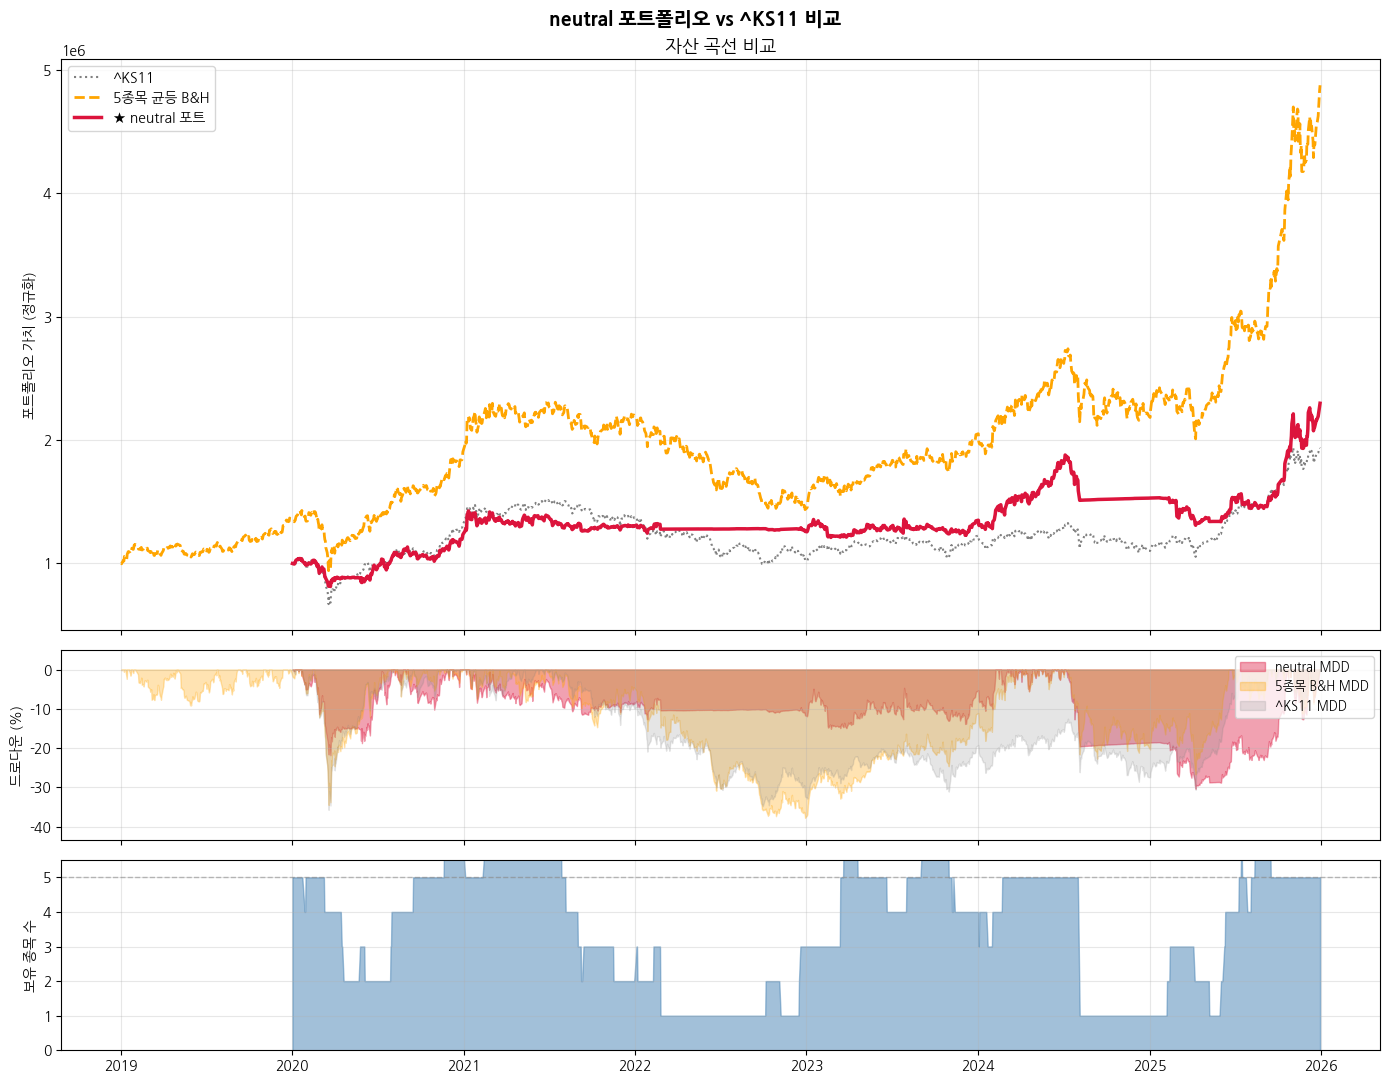

In [8]:
names_all = wf_info['names_all']

plot_equity_curves(
    pf_wf, pf_bh, names_all, len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### 6-3. 연도별 실제 손익 (원화 기준)

> 100만원 초기 자본 기준 실제 원화 손익을 연도별로 확인합니다.

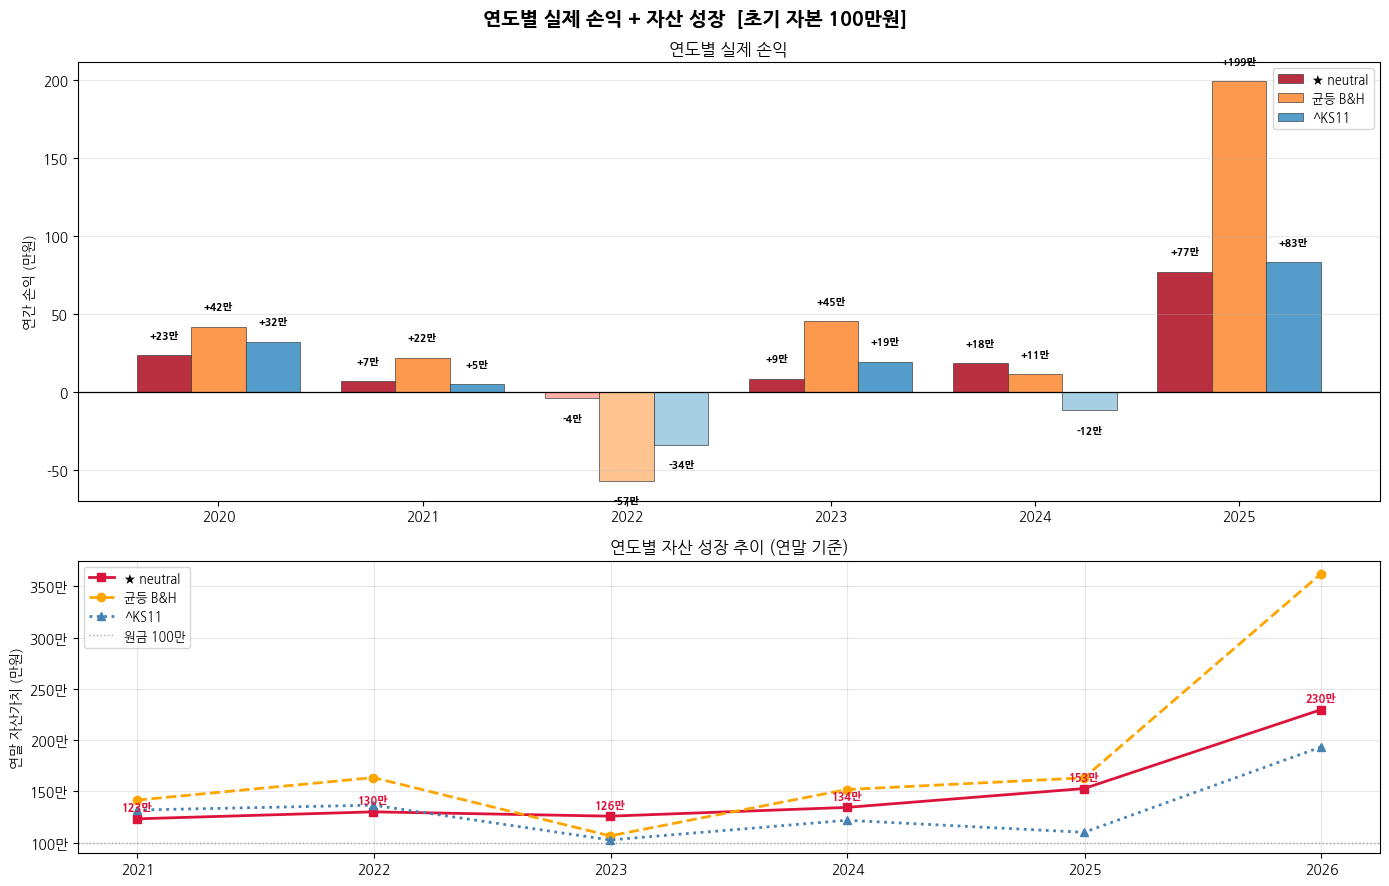


초기 자본: 100만원

  연도      전략 잔고      전략 손익     B&H 잔고     B&H 손익
----------------------------------------------------
2020      123만       +23만      141만       +42만
2021      130만        +7만      163만       +22만
2022      126만        -4만      107만       -57만
2023      134만        +9만      152만       +45만
2024      153만       +18만      163만       +11만
2025      230만       +77만      362만      +199만

  ■ 최종 잔고: 230만원  ■ 총 손익: +130만  ■ 수익 연도: 5/6


In [9]:
plot_yearly_pnl(
    pf_wf, pf_bh,
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### 6-4. 연도별 수익률 비교

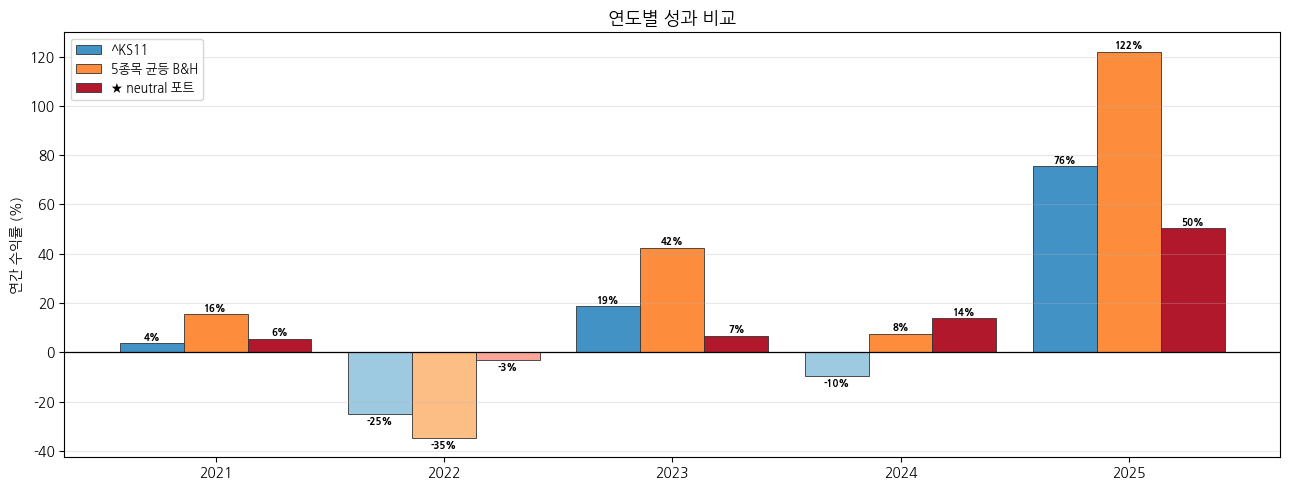

In [10]:
plot_yearly_returns(
    pf_wf, pf_bh, n=len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### 6-5. MDD Depth + Duration 비교

=== MDD 비교 ===
  KOSPI (벤치마크)        : MDD 35.7%  Duration 1022일
  5종목 균등 B&H          : MDD 37.8%  Duration 657일
  neutral             : MDD 30.3%  Duration 758일

MDD depth: KOSPI -35.7% → neutral -30.3% (✅ 개선)


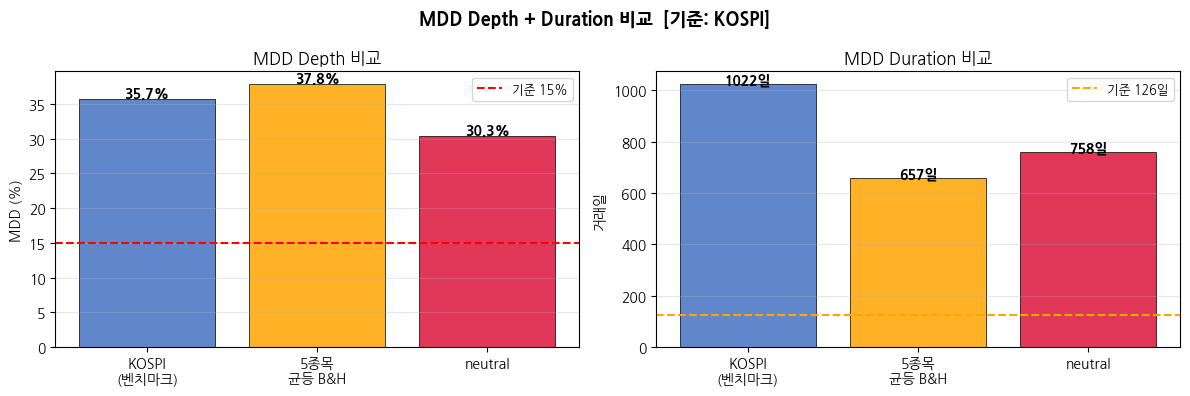

In [11]:
plot_mdd_comparison(
    pf_wf, pf_bh, kospi,
    n=len(names),
    profile_name=PROFILE_NAME,
)

### 6-6. 종목별 보유 비중 히트맵

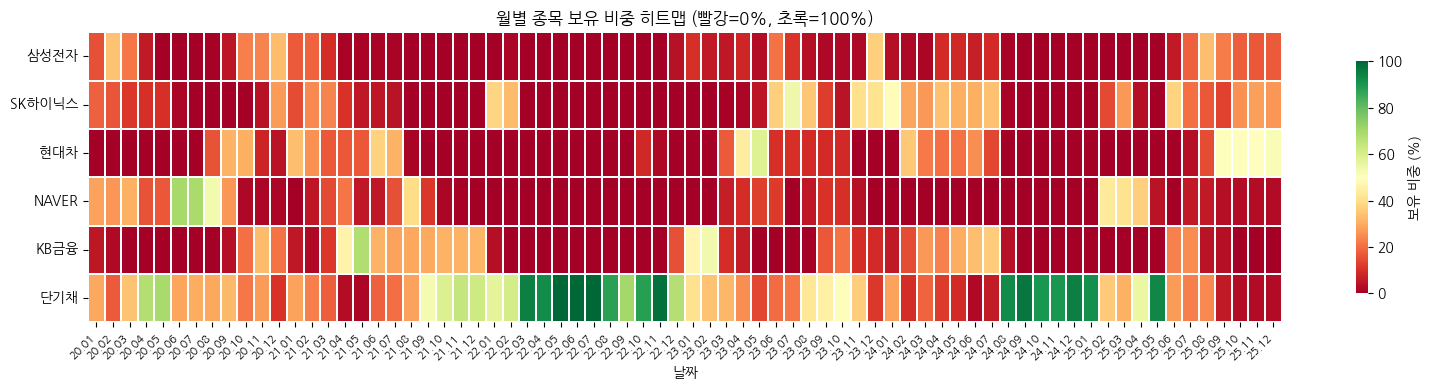


=== 종목별 평균 포지션 비중 ===
  삼성전자        : 6.9%  (최대 70.0%)
  SK하이닉스      : 12.9%  (최대 70.0%)
  현대차         : 11.1%  (최대 70.0%)
  NAVER       : 9.7%  (최대 70.0%)
  KB금융        : 11.9%  (최대 70.1%)
  단기채         : 42.9%  (최대 100.0%)


In [12]:
plot_weight_heatmap(pf_wf, names_all)

### 6-7. 종목별 수익 기여도

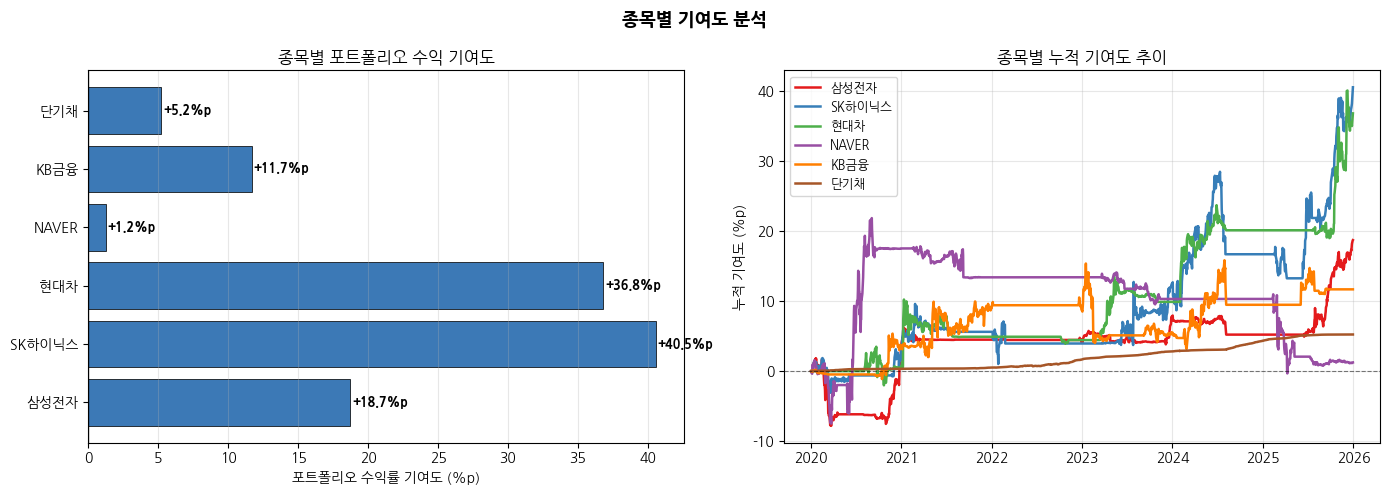

In [13]:
plot_contribution(pf_wf, wf_info['close_df_all'], names_all)

### 6-8. 분산투자 효과 (상관관계 + 변동성)

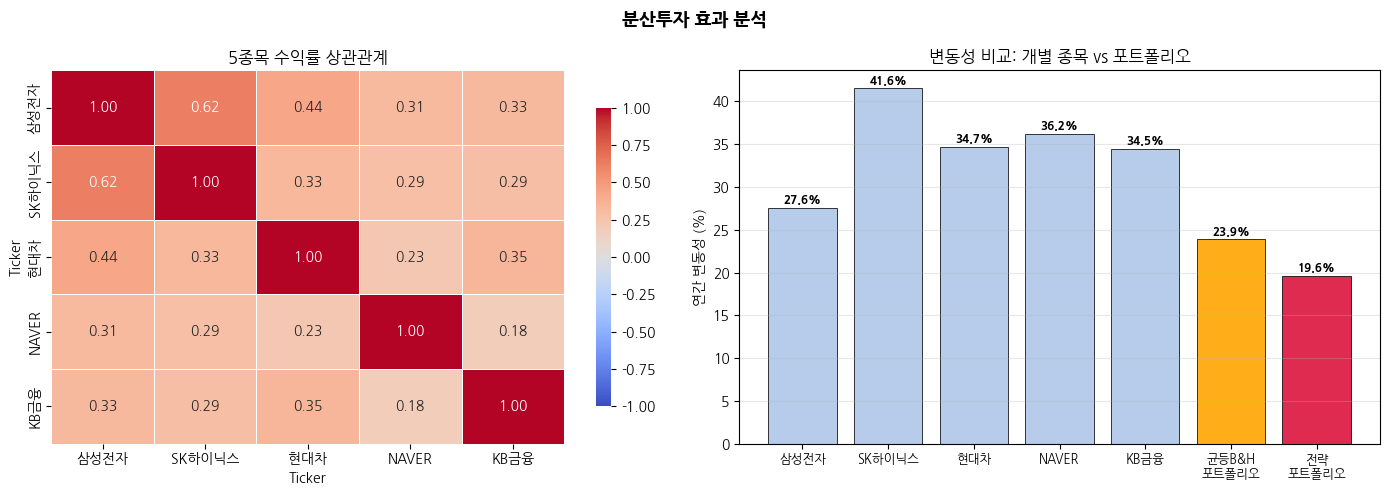

In [14]:
plot_diversification(pf_wf, close_df, names)

### 6-9. 분기별 수익률 비교

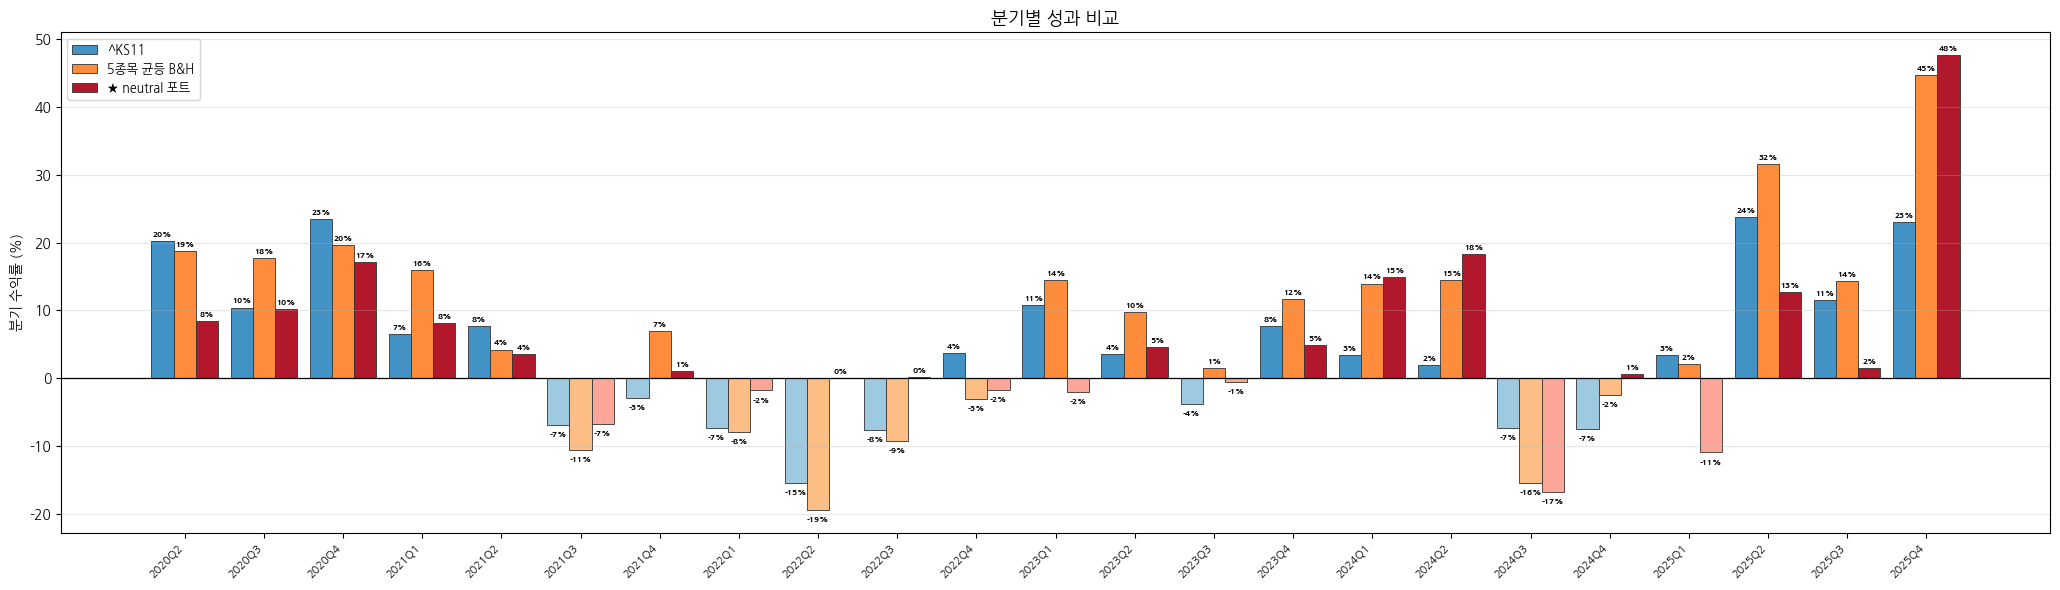

In [15]:
plot_quarterly_returns(
    pf_wf, pf_bh, n=len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### 6-10. 월별 수익률 히트맵

> 빨강 = 손실, 초록 = 수익. 마지막 열 = 연간 복리 수익률.

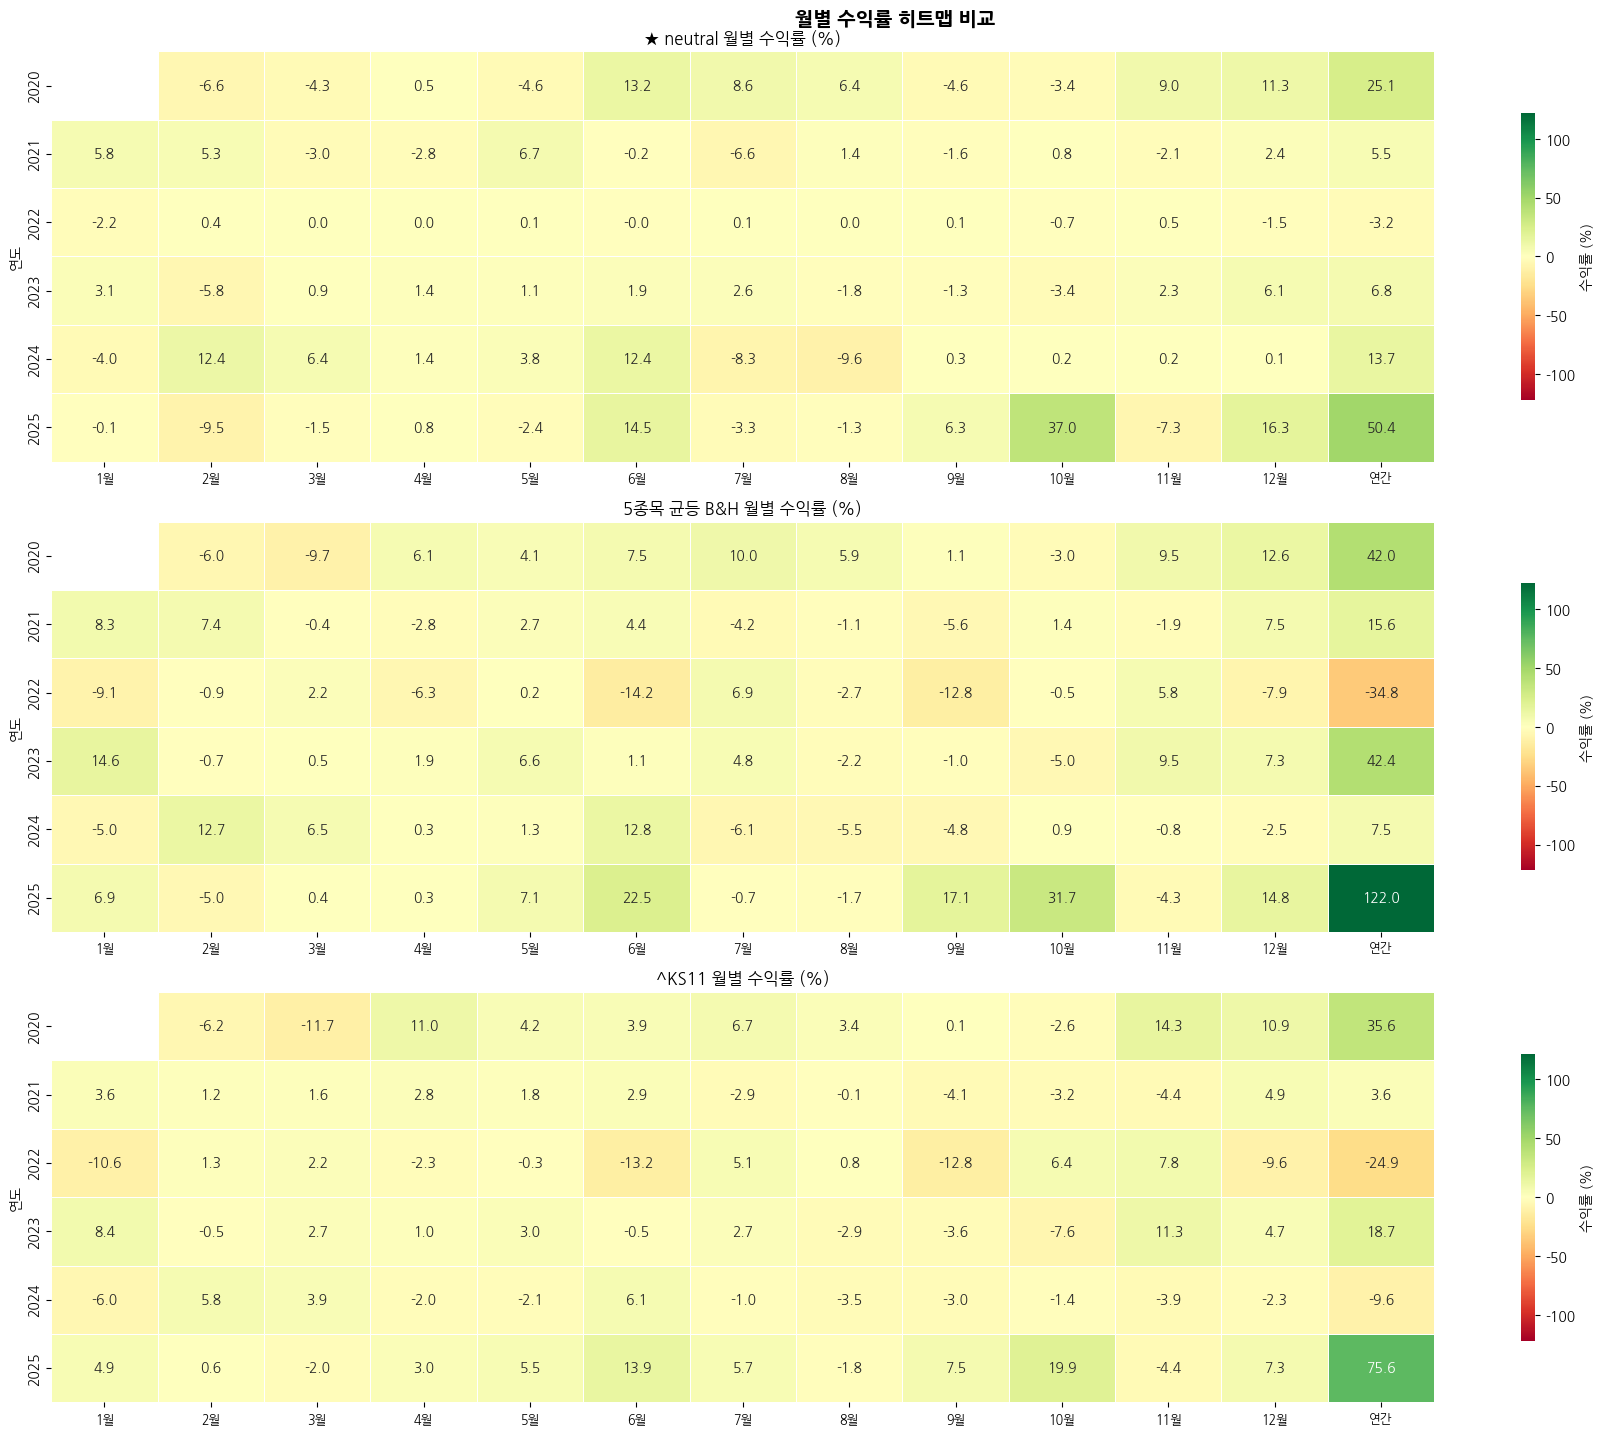

In [16]:
plot_monthly_heatmap(
    pf_wf, pf_bh, n=len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

---
## 7. 기간별 수익률 상세 테이블

In [17]:
tbl_yearly = build_period_stats_table(
    pf_wf, pf_bh,
    benchmark_series=kospi,
    freq='Y',
    profile_name=PROFILE_NAME,
)
print('=== 연도별 수익률 비교 ===\n')
tbl_yearly

=== 연도별 수익률 비교 ===



,neutral(%),B&H(%),KOSPI(%),neutral-KOSPI(%p),neutral-B&H(%p)
2021,5.53,15.55,3.63,1.91,-10.02
2022,-3.24,-34.78,-24.89,21.66,31.55
2023,6.79,42.42,18.73,-11.94,-35.63
2024,13.71,7.51,-9.63,23.35,6.20
2025,50.35,121.96,75.63,-25.28,-71.61


In [18]:
tbl_quarterly = build_period_stats_table(
    pf_wf, pf_bh,
    benchmark_series=kospi,
    freq='Q',
    profile_name=PROFILE_NAME,
)
print('=== 분기별 수익률 비교 ===\n')
tbl_quarterly

=== 분기별 수익률 비교 ===



,neutral(%),B&H(%),KOSPI(%),neutral-KOSPI(%p),neutral-B&H(%p)
2020Q2,8.48,18.74,20.16,-11.68,-10.26
2020Q3,10.20,17.76,10.41,-0.21,-7.55
2020Q4,17.09,19.60,23.44,-6.34,-2.51
2021Q1,8.14,15.91,6.54,1.60,-7.77
2021Q2,3.56,4.22,7.68,-4.13,-0.66
2021Q3,-6.73,-10.57,-6.91,0.18,3.84
2021Q4,1.03,6.96,-2.97,4.00,-5.93
2022Q1,-1.82,-7.97,-7.39,5.56,6.15
2022Q2,0.07,-19.43,-15.41,15.48,19.50
2022Q3,0.22,-9.28,-7.59,7.81,9.50
